In [ ]:
import numpy as np
import torch
from torch import nn, optim
import torch.nn.functional as F
import torchvision
import matplotlib.pyplot as plt
import tqdm
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from torchsummary import summary
import csv
import scipy.ndimage


In [11]:
DEVICE = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: mps


Much of the inspiration and template for the codebase here has come from my WXML Project, in which we work on Backdooring into ML Models that we build. One ML Model we've built is an MNIST/Fashion-MNIST Classifier using CNNs and simple NN's. So I already have prior experience building classes for this type of work and have referenced my knowledge from past experiences and projects.

In [ ]:
train_dataset = torchvision.datasets.FashionMNIST(
    'data/', train=True, download=True,
    transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize((0.1307,), (0.3081,))
    ])
)
test_dataset = torchvision.datasets.FashionMNIST(
    'data/', train=False, download=True,
    transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize((0.1307,), (0.3081,))
    ])
)

train_indices, val_indices, _, _ = train_test_split(
    range(len(train_dataset)),
    train_dataset.targets,
    stratify=train_dataset.targets,
    test_size=0.1
)
train_split = Subset(train_dataset, train_indices)
val_split = Subset(train_dataset, val_indices)

augment_transform = torchvision.transforms.Compose([
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomAffine(degrees=5, translate=(0.05, 0.05), scale=(0.95, 1.05), shear=0.05),
    torchvision.transforms.ColorJitter(brightness=0.1, contrast=0.1),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.1307,), (0.3081,))
])
train_split.dataset.transform = augment_transform

train_batch_size = 512
test_batch_size  = 256
train_batches = DataLoader(train_split, batch_size=train_batch_size, shuffle=True)
val_batches   = DataLoader(val_split, batch_size=train_batch_size, shuffle=True)
test_batches  = DataLoader(test_dataset, batch_size=test_batch_size, shuffle=False)

print("Number of training batches:", len(train_batches))
print("Number of validation batches:", len(val_batches))
print("Number of test batches:", len(test_batches))

Number of training batches: 106
Number of validation batches: 12
Number of test batches: 40


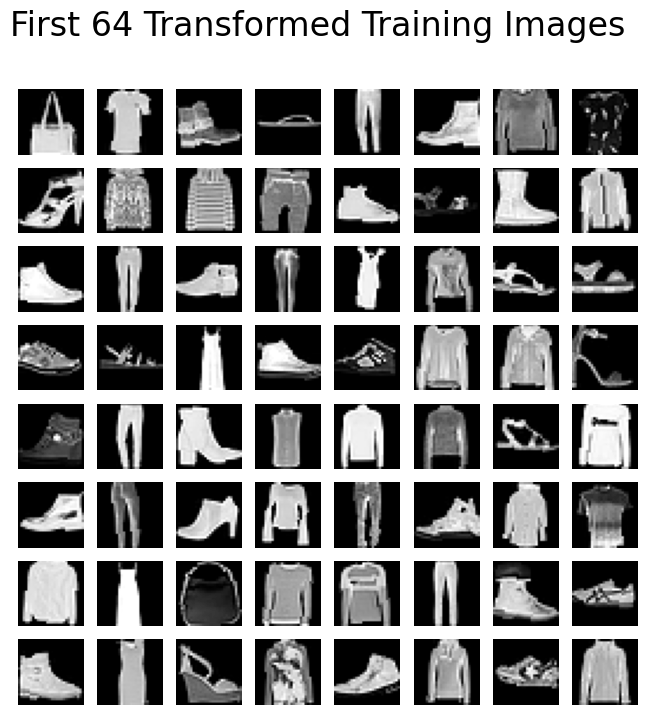

In [ ]:
def plot_images(dataset, N, title):
    fig, ax = plt.subplots(N, N, figsize=(8, 8))
    for i in range(N):
        for j in range(N):
            img, _ = dataset[(N) * i + j]
            ax[i, j].imshow(img.squeeze(), cmap="gray")
            ax[i, j].axis("off")
    fig.suptitle(title, fontsize=24)
    plt.show()


plot_images(train_split, 8, "First 64 Transformed Training Images")

def calculate_accuracy(y_true, y_pred):

    _, predicted = torch.max(y_pred, 1)
    correct = (predicted == y_true).sum().item()
    return correct / y_true.size(0)

def train_model(model, train_loader, val_loader, lr, num_epochs):
    model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=3, factor=0.5)
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        running_accuracy = 0.0
        for inputs, labels in tqdm.tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            running_accuracy += calculate_accuracy(labels, outputs)
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = running_accuracy / len(train_loader)
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)
        
        # Validation phase here
        model.eval()
        val_loss = 0.0
        val_acc = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                val_acc += calculate_accuracy(labels, outputs)
        val_loss /= len(val_loader)
        val_acc /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        scheduler.step(val_acc)
        
        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    return train_losses, val_losses, train_accuracies, val_accuracies

def test_model(model, test_loader):
    model.to(DEVICE)
    model.eval()
    test_loss = 0.0
    test_acc = 0.0
    criterion = nn.CrossEntropyLoss()
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            test_acc += calculate_accuracy(labels, outputs)
    test_loss /= len(test_loader)
    test_acc /= len(test_loader)
    return test_loss, test_acc

def plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies):
    # Plot loss and accuracy curves over epochs
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(epochs, train_losses, marker='o', label="Train Loss")
    plt.plot(epochs, val_losses, marker='o', label="Val Loss")
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss vs. Epoch')
    plt.legend()
    
    plt.subplot(1,2,2)
    plt.plot(epochs, train_accuracies, marker='o', label="Train Accuracy")
    plt.plot(epochs, val_accuracies, marker='o', label="Val Accuracy")
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs. Epoch')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

def plot_training_stats(train_losses, val_losses, train_accuracies, val_accuracies, label_suffix):
    epochs = range(1, len(train_losses) + 1)
    plt.subplot(1, 3, 1)
    plt.plot(epochs, train_losses, label=f'Train Loss {label_suffix}')
    plt.subplot(1, 3, 2)
    plt.plot(epochs, train_accuracies, label=f'Train Acc {label_suffix}')
    plt.subplot(1, 3, 3)
    plt.plot(epochs, val_accuracies, label=f'Val Acc {label_suffix}')

def read_stats_from_csv(file_name):
    train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []
    with open(file_name, mode='r') as file:
        reader = csv.DictReader(file)
        for row in reader:
            train_losses.append(float(row["Train Loss"]))
            val_losses.append(float(row["Val Loss"]))
            train_accuracies.append(float(row["Train Accuracy"]))
            val_accuracies.append(float(row["Val Accuracy"]))
    return train_losses, val_losses, train_accuracies, val_accuracies

In [ ]:
class FashionMNIST_FCN(nn.Module):
    # 100K-parameter
    def __init__(self):
        super(FashionMNIST_FCN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 110)
        self.fc2 = nn.Linear(110, 110)
        self.fc3 = nn.Linear(110, 10)
    
    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

class FashionMNIST_FCN_Small(nn.Module):
    # 50K-parameter
    def __init__(self):
        super(FashionMNIST_FCN_Small, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 60)
        self.fc2 = nn.Linear(60, 10)
    
    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

class FashionMNIST_FCN_Large(nn.Module):
    # 200K-parameter FCN!!
    def __init__(self):
        super(FashionMNIST_FCN_Large, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 200)
        self.fc2 = nn.Linear(200, 200)
        self.fc3 = nn.Linear(200, 10)
    
    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [ ]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1):
        super(DepthwiseSeparableConv, self).__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size, stride,
                                   padding=kernel_size//2, groups=in_channels, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.pointwise = nn.Conv2d(in_channels, out_channels, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
    
    def forward(self, x):
        x = self.depthwise(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pointwise(x)
        x = self.bn2(x)
        x = F.relu(x)
        return x

class FashionMNIST_CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(FashionMNIST_CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 24, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(24)
        self.layer1 = DepthwiseSeparableConv(24, 48)
        self.layer2 = DepthwiseSeparableConv(48, 96, stride=2)
        self.layer3 = DepthwiseSeparableConv(96, 96)
        self.layer4 = DepthwiseSeparableConv(96, 192, stride=2)
        self.layer5 = DepthwiseSeparableConv(192, 192)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Linear(192, 112)
        self.fc2 = nn.Linear(112, num_classes)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
class FashionMNIST_CNN_50k(nn.Module):
    # 50K-parameter
    def __init__(self, num_classes=10):
        super(FashionMNIST_CNN_50k, self).__init__()
        self.conv1 = nn.Conv2d(1, 12, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(12)
        self.layer1 = DepthwiseSeparableConv(12, 24)
        self.layer2 = DepthwiseSeparableConv(24, 48, stride=2)
        self.layer3 = DepthwiseSeparableConv(48, 96)
        self.layer4 = DepthwiseSeparableConv(96, 128, stride=2)
        self.layer5 = DepthwiseSeparableConv(128, 128)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Linear(128, 60)
        self.fc2 = nn.Linear(60, num_classes)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
class FashionMNIST_CNN_20k(nn.Module):
    #20 k
    def __init__(self, num_classes=10):
        super(FashionMNIST_CNN_20k, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.layer1 = DepthwiseSeparableConv(16, 32)
        self.layer2 = DepthwiseSeparableConv(32, 32, stride=2)
        self.layer3 = DepthwiseSeparableConv(32, 64)
        self.layer4 = DepthwiseSeparableConv(64, 84, stride=2)
        self.layer5 = DepthwiseSeparableConv(84, 84)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(84, num_classes)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

In [ ]:
class FashionMNIST_CNN_10k(nn.Module):
    # 10k
    def __init__(self, num_classes=10):
        super(FashionMNIST_CNN_10k, self).__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(8)
        self.layer1 = DepthwiseSeparableConv(8, 16)
        self.layer2 = DepthwiseSeparableConv(16, 16, stride=2)
        self.layer3 = DepthwiseSeparableConv(16, 32)
        self.layer4 = DepthwiseSeparableConv(32, 64, stride=2)
        self.layer5 = DepthwiseSeparableConv(64, 64)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(64, num_classes)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

## Not required to make a visual but I saw examples of it online and decided to include it!

In [ ]:


def generate_class_image(model, target_class, num_iterations=500, learning_rate=0.1):
    model.eval()
    input_image = torch.zeros(1, 1, 28, 28, device=DEVICE, requires_grad=True)
    optimizer = optim.Adam([input_image], lr=learning_rate)
    
    for i in range(num_iterations):
        optimizer.zero_grad()
        output = model(input_image)
        loss = -output[0, target_class]
        smoothness_loss = (torch.mean(torch.abs(input_image[:, :, 1:, :] - input_image[:, :, :-1, :])) +
                           torch.mean(torch.abs(input_image[:, :, :, 1:] - input_image[:, :, :, :-1])))
        loss += 10.0 * smoothness_loss
        # L2 regularization
        l2_loss = torch.mean(input_image ** 2)
        loss += 0.01 * l2_loss
        l1_loss = torch.mean(torch.abs(input_image))
        loss += 0.01 * l1_loss
        tv_loss = (torch.mean(torch.abs(input_image[:, :, 1:, :] - input_image[:, :, :-1, :])) +
                   torch.mean(torch.abs(input_image[:, :, :, 1:] - input_image[:, :, :, :-1])))
        loss += 0.5 * tv_loss
        loss.backward()
        optimizer.step()
        
        if i != num_iterations - 1:
            input_image.data = input_image.data + torch.randn_like(input_image) * 0.005
        
        input_image.data.clamp_(0, 1)
    
    return input_image.detach().cpu().squeeze().numpy()


### Again, most of my code has been referenced from HW 4 as well as template code provided to us in CSE 579 and similarly available to me from my research projects.

Training FCN 100K model...


Epoch 1/10:   0%|          | 0/106 [00:00<?, ?it/s]

Epoch 1/10: 100%|██████████| 106/106 [00:13<00:00,  8.04it/s]


Epoch [1/10], Train Loss: 0.8567, Train Acc: 0.6925, Val Loss: 0.6014, Val Acc: 0.7858


Epoch 2/10: 100%|██████████| 106/106 [00:13<00:00,  8.02it/s]


...

Epoch [8/10], Train Loss: 0.4247, Train Acc: 0.8450, Val Loss: 0.4138, Val Acc: 0.8551


Epoch 9/10: 100%|██████████| 106/106 [00:17<00:00,  5.94it/s]


Epoch [9/10], Train Loss: 0.4107, Train Acc: 0.8491, Val Loss: 0.3981, Val Acc: 0.8506


Epoch 10/10: 100%|██████████| 106/106 [00:18<00:00,  5.83it/s]


Epoch [10/10], Train Loss: 0.3990, Train Acc: 0.8539, Val Loss: 0.3939, Val Acc: 0.8569
CNN 10K Test Loss: 0.4036, Test Accuracy: 0.8549


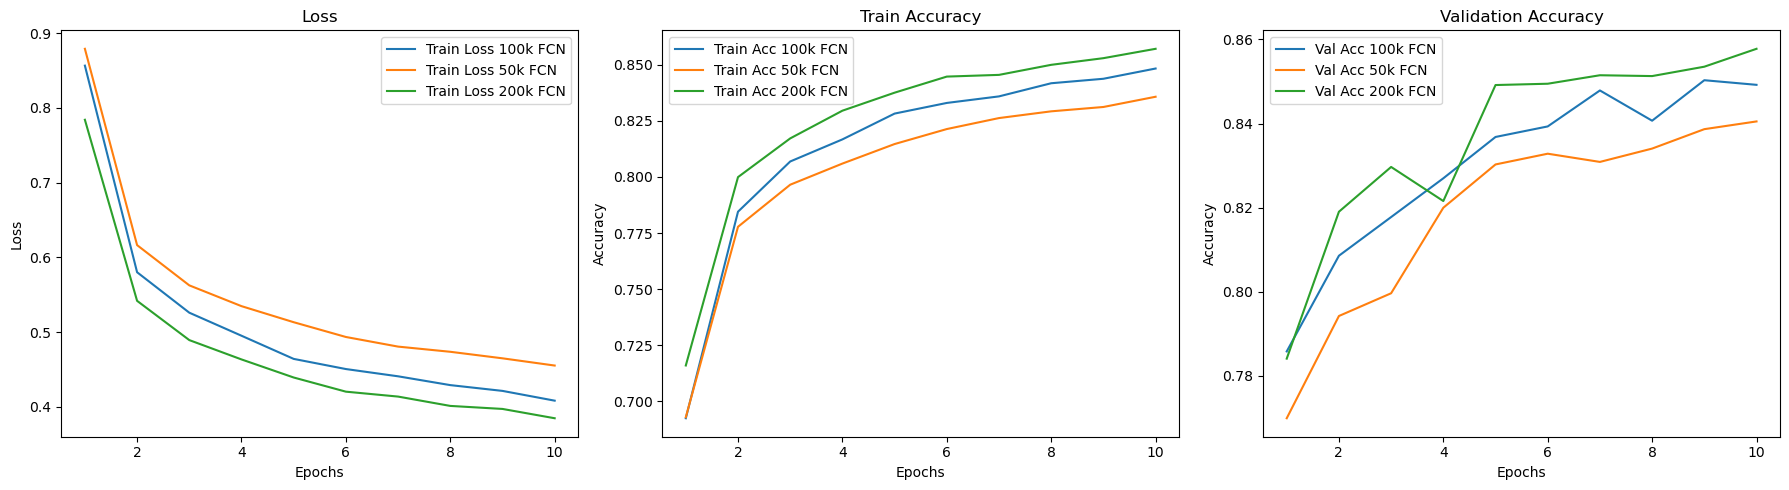

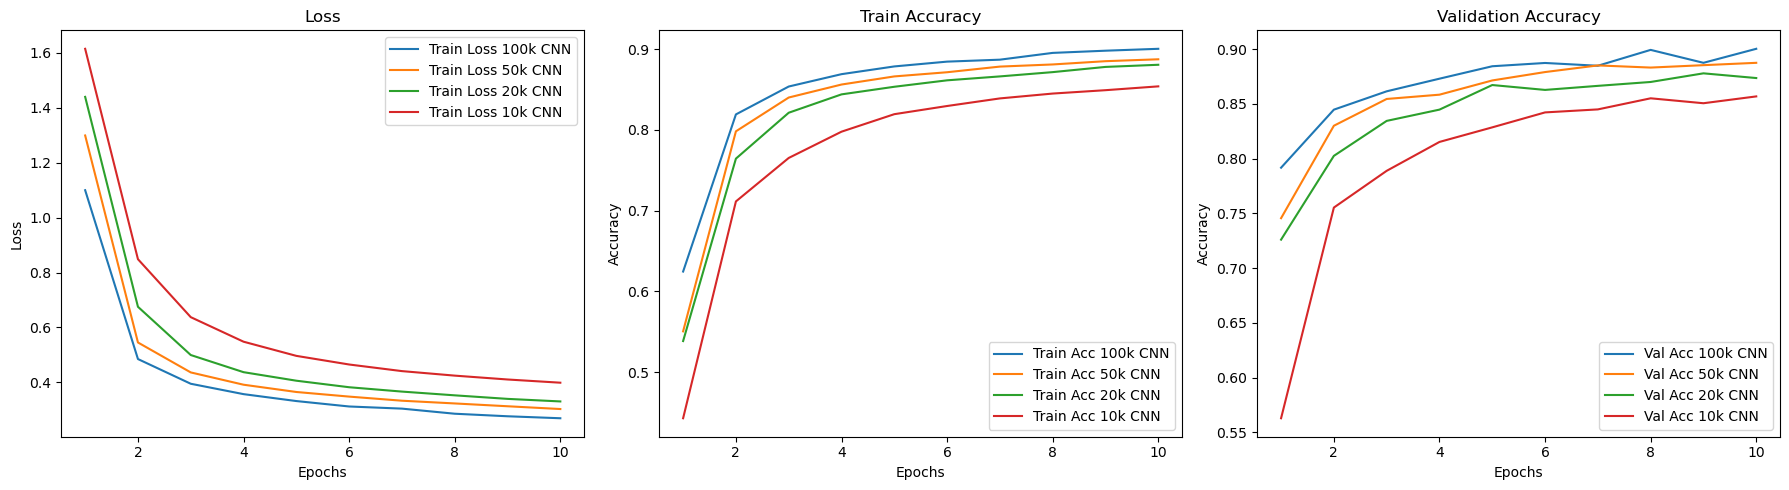

Generating synthesized image for class 5 using CNN 100K model...


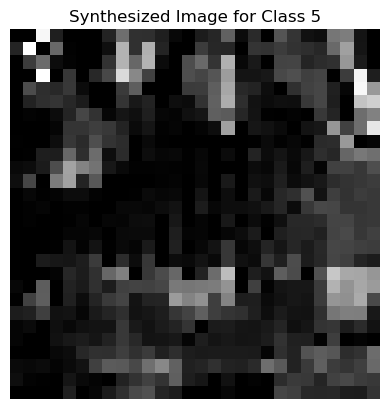

In [ ]:
if __name__ == '__main__':
    num_epochs = 10 # Changed this from 20 to 10, although 20 would probably allow for more training time and better results.
    lr = 1e-3 # Can be changed!

    model_100k_FCN = FashionMNIST_FCN().to(DEVICE)
    print("Training FCN 100K model...")
    train_losses_100k, val_losses_100k, train_acc_100k, val_acc_100k = train_model(model_100k_FCN, train_batches, val_batches, lr, num_epochs)
    test_loss_100k, test_acc_100k = test_model(model_100k_FCN, test_batches)
    print(f"FCN 100K Test Loss: {test_loss_100k:.4f}, Test Accuracy: {test_acc_100k:.4f}")
    with open('100kFCN_Stats.csv', mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Epoch", "Train Loss", "Train Accuracy", "Val Loss", "Val Accuracy"])
        for epoch in range(num_epochs):
            writer.writerow([epoch+1, train_losses_100k[epoch], train_acc_100k[epoch], val_losses_100k[epoch], val_acc_100k[epoch]])
    # 50k
    model_50k_FCN = FashionMNIST_FCN_Small().to(DEVICE)
    print("Training FCN 50K model...")
    train_losses_50k, val_losses_50k, train_acc_50k, val_acc_50k = train_model(model_50k_FCN, train_batches, val_batches, lr, num_epochs)
    test_loss_50k, test_acc_50k = test_model(model_50k_FCN, test_batches)
    print(f"FCN 50K Test Loss: {test_loss_50k:.4f}, Test Accuracy: {test_acc_50k:.4f}")
    with open('50kFCN_Stats.csv', mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Epoch", "Train Loss", "Train Accuracy", "Val Loss", "Val Accuracy"])
        for epoch in range(num_epochs):
            writer.writerow([epoch+1, train_losses_50k[epoch], train_acc_50k[epoch], val_losses_50k[epoch], val_acc_50k[epoch]])
    
    # FCN 200K
    model_200k_FCN = FashionMNIST_FCN_Large().to(DEVICE)
    print("Training FCN 200K model...")
    train_losses_200k, val_losses_200k, train_acc_200k, val_acc_200k = train_model(model_200k_FCN, train_batches, val_batches, lr, num_epochs)
    test_loss_200k, test_acc_200k = test_model(model_200k_FCN, test_batches)
    print(f"FCN 200K Test Loss: {test_loss_200k:.4f}, Test Accuracy: {test_acc_200k:.4f}")
    with open('200kFCN_Stats.csv', mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Epoch", "Train Loss", "Train Accuracy", "Val Loss", "Val Accuracy"])
        for epoch in range(num_epochs):
            writer.writerow([epoch+1, train_losses_200k[epoch], train_acc_200k[epoch], val_losses_200k[epoch], val_acc_200k[epoch]])
    
    # CNN 100K Model    
    model_100k_CNN = FashionMNIST_CNN().to(DEVICE)
    print("Training CNN 100K model...")
    train_losses_100kCNN, val_losses_100kCNN, train_acc_100kCNN, val_acc_100kCNN = train_model(model_100k_CNN, train_batches, val_batches, lr, num_epochs)
    test_loss_100kCNN, test_acc_100kCNN = test_model(model_100k_CNN, test_batches)
    print(f"CNN 100K Test Loss: {test_loss_100kCNN:.4f}, Test Accuracy: {test_acc_100kCNN:.4f}")
    with open('100kCNN_Stats.csv', mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Epoch", "Train Loss", "Train Accuracy", "Val Loss", "Val Accuracy"])
        for epoch in range(num_epochs):
            writer.writerow([epoch+1, train_losses_100kCNN[epoch], train_acc_100kCNN[epoch], val_losses_100kCNN[epoch], val_acc_100kCNN[epoch]])
    
    # CNN 50K Model
    model_50k_CNN = FashionMNIST_CNN_50k().to(DEVICE)
    print("Training CNN 50K model...")
    train_losses_50kCNN, val_losses_50kCNN, train_acc_50kCNN, val_acc_50kCNN = train_model(model_50k_CNN, train_batches, val_batches, lr, num_epochs)
    test_loss_50kCNN, test_acc_50kCNN = test_model(model_50k_CNN, test_batches)
    print(f"CNN 50K Test Loss: {test_loss_50kCNN:.4f}, Test Accuracy: {test_acc_50kCNN:.4f}")
    with open('50kCNN_Stats.csv', mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Epoch", "Train Loss", "Train Accuracy", "Val Loss", "Val Accuracy"])
        for epoch in range(num_epochs):
            writer.writerow([epoch+1, train_losses_50kCNN[epoch], train_acc_50kCNN[epoch], val_losses_50kCNN[epoch], val_acc_50kCNN[epoch]])
    
    # CNN 20K Model
    model_20k_CNN = FashionMNIST_CNN_20k().to(DEVICE)
    print("Training CNN 20K model...")
    train_losses_20kCNN, val_losses_20kCNN, train_acc_20kCNN, val_acc_20kCNN = train_model(model_20k_CNN, train_batches, val_batches, lr, num_epochs)
    test_loss_20kCNN, test_acc_20kCNN = test_model(model_20k_CNN, test_batches)
    print(f"CNN 20K Test Loss: {test_loss_20kCNN:.4f}, Test Accuracy: {test_acc_20kCNN:.4f}")
    with open('20kCNN_Stats.csv', mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Epoch", "Train Loss", "Train Accuracy", "Val Loss", "Val Accuracy"])
        for epoch in range(num_epochs):
            writer.writerow([epoch+1, train_losses_20kCNN[epoch], train_acc_20kCNN[epoch], val_losses_20kCNN[epoch], val_acc_20kCNN[epoch]])
    
    # CNN 10K Model
    model_10k_CNN = FashionMNIST_CNN_10k().to(DEVICE)
    print("Training CNN 10K model...")
    train_losses_10kCNN, val_losses_10kCNN, train_acc_10kCNN, val_acc_10kCNN = train_model(model_10k_CNN, train_batches, val_batches, lr, num_epochs)
    test_loss_10kCNN, test_acc_10kCNN = test_model(model_10k_CNN, test_batches)
    print(f"CNN 10K Test Loss: {test_loss_10kCNN:.4f}, Test Accuracy: {test_acc_10kCNN:.4f}")
    with open('10kCNN_Stats.csv', mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Epoch", "Train Loss", "Train Accuracy", "Val Loss", "Val Accuracy"])
        for epoch in range(num_epochs):
            writer.writerow([epoch+1, train_losses_10kCNN[epoch], train_acc_10kCNN[epoch], val_losses_10kCNN[epoch], val_acc_10kCNN[epoch]])
    
    # Plot Training Curves
    plt.figure(figsize=(18,5))
    train_losses_100k_csv, val_losses_100k_csv, train_acc_100k_csv, val_acc_100k_csv = read_stats_from_csv('100kFCN_Stats.csv')
    plot_training_stats(train_losses_100k_csv, val_losses_100k_csv, train_acc_100k_csv, val_acc_100k_csv, "100k FCN")
    train_losses_50k_csv, val_losses_50k_csv, train_acc_50k_csv, val_acc_50k_csv = read_stats_from_csv('50kFCN_Stats.csv')
    plot_training_stats(train_losses_50k_csv, val_losses_50k_csv, train_acc_50k_csv, val_acc_50k_csv, "50k FCN")
    train_losses_200k_csv, val_losses_200k_csv, train_acc_200k_csv, val_acc_200k_csv = read_stats_from_csv('200kFCN_Stats.csv')
    plot_training_stats(train_losses_200k_csv, val_losses_200k_csv, train_acc_200k_csv, val_acc_200k_csv, "200k FCN")
    
    plt.subplot(1,3,1)
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.subplot(1,3,2)
    plt.title('Train Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.subplot(1,3,3)
    plt.title('Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(18,5))
    train_losses_100kCNN_csv, val_losses_100kCNN_csv, train_acc_100kCNN_csv, val_acc_100kCNN_csv = read_stats_from_csv('100kCNN_Stats.csv')
    plot_training_stats(train_losses_100kCNN_csv, val_losses_100kCNN_csv, train_acc_100kCNN_csv, val_acc_100kCNN_csv, "100k CNN")
    train_losses_50kCNN_csv, val_losses_50kCNN_csv, train_acc_50kCNN_csv, val_acc_50kCNN_csv = read_stats_from_csv('50kCNN_Stats.csv')
    plot_training_stats(train_losses_50kCNN_csv, val_losses_50kCNN_csv, train_acc_50kCNN_csv, val_acc_50kCNN_csv, "50k CNN")
    train_losses_20kCNN_csv, val_losses_20kCNN_csv, train_acc_20kCNN_csv, val_acc_20kCNN_csv = read_stats_from_csv('20kCNN_Stats.csv')
    plot_training_stats(train_losses_20kCNN_csv, val_losses_20kCNN_csv, train_acc_20kCNN_csv, val_acc_20kCNN_csv, "20k CNN")
    train_losses_10kCNN_csv, val_losses_10kCNN_csv, train_acc_10kCNN_csv, val_acc_10kCNN_csv = read_stats_from_csv('10kCNN_Stats.csv')
    plot_training_stats(train_losses_10kCNN_csv, val_losses_10kCNN_csv, train_acc_10kCNN_csv, val_acc_10kCNN_csv, "10k CNN")
    
    plt.subplot(1,3,1)
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.subplot(1,3,2)
    plt.title('Train Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.subplot(1,3,3)
    plt.title('Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("Generating synthesized image for class 5 using CNN 100K model: ")
    class_image = generate_class_image(model_100k_CNN, target_class=5, num_iterations=1000, learning_rate=0.01)
    plt.imshow(class_image.squeeze(), cmap='gray')
    plt.title("Synthesized Image for Class 5")
    plt.axis('off')
    plt.show()